# JLT invited — end-to-end BPAM-4, "complex" receiver (Asfand-comparable)

Reproduces the curves of `JLT_invited_OFC v3/figs/complex_osnr_dario.pdf`: **BER vs OSNR** and
**BER vs Eb/N0** for the end-to-end autoencoder with the *complex* RX-DSP — fully connected
32-64-16 with sigmoid output, context window 5 symbols ($L_y=10$ at $s'=2$) — at fixed
`N_DAC = 6` and `N_ADC` = 8 / 6 / 5, **without** the differential precoder (the A/B winner).
The TX-DSP is our fully connected 16 (5-symbol memory, $L_b=10$).

The chain comes from `functions/scenarios.py` (`asfand_complex`), shared with the campaign
drivers: chain, seeds and step counts are identical, so with the campaign checkpoints in
`results/` this notebook reproduces the published numbers without retraining.

* Axis: `OSNR = Eb/N0 + 2.05 dB` (signal 1 pol, ASE 2 pol, Bref 12.5 GHz — Luca 2026-07-16).
* Each network is evaluated **natively on both grids** (integer Eb/N0 9–18 and integer OSNR
  11–20): no axis conversion is ever applied to a BER.
* The BPAM + adaptive-equalizer reference comes from the MATLAB simulator
  (`PAM_bipolare_DD_nuovi__sorgenti/driver_baseline_jlt.m`, mode `'grid'`) simulated directly
  on the integer-OSNR grid: `results/paper/bpam_ae_reference_osnrgrid.txt`.


## 1. Setup and knobs

In [9]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from scenarios import asfand_complex, checkpoint_name, OSNR_OFFSET_DB, TRAIN_EBN0_DB, TRAIN_STEPS
from train import train, evaluate

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------------- knobs ----------------
ADC_BITS   = [8, 6, 5]        # the family of the paper figure
PRECODE    = False            # differential precoder at the DPD input (A/B: False is better)
SEED       = 0
NUM_STEPS  = TRAIN_STEPS      # 100k
FORCE_RETRAIN = True

EBN0_GRID = list(range(9, 19))
OSNR_GRID = list(range(11, 21))
EBN0_FOR_OSNR = [o - OSNR_OFFSET_DB for o in OSNR_GRID]

def num_symbols(ebn0_db):
    return 4_000_000 if ebn0_db <= 14.0 else 16_000_000

print(asfand_complex(adc_bits=6, precode=PRECODE).summary())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 40 GHz  (2 sps, Nyquist 20 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: False)
modulator            : mzm  (MZM 30 GHz, 1 segments)
pulse shape          : freq-rect 20 GHz (brickwall)
equalizer            : DPD (TX) + FFE (RX), trained jointly
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz


## 2. Train (or load) one network per ADC resolution

The checkpoint names match the campaign ones, so the published networks are loaded directly.

In [10]:
from transmitter import Transmitter
from receiver import Receiver
from channel import OpticalChannel

def load_or_train(adc_bits, force_retrain=False):
    cfg = asfand_complex(adc_bits=adc_bits, precode=PRECODE)
    path = checkpoint_name(cfg, 0, 0, adc_bits, SEED, NUM_STEPS)
    os.makedirs(os.path.dirname(path), exist_ok=True)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    if os.path.exists(path) and not force_retrain:
        tx, ch, rx = Transmitter(cfg).to(device), OpticalChannel(cfg).to(device), Receiver(cfg).to(device)
        state = torch.load(path, map_location=device, weights_only=True)
        tx.load_state_dict(state["tx"]); rx.load_state_dict(state["rx"])
        tx.eval(); rx.eval()
        print(f"loaded {path}")
    else:
        print(f"training N_ADC={adc_bits} ({NUM_STEPS} steps, train@Eb/N0={TRAIN_EBN0_DB})")
        tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS,
                           ebn0_range=(TRAIN_EBN0_DB, TRAIN_EBN0_DB))
        torch.save({"tx": tx.state_dict(), "rx": rx.state_dict()}, path)
        print(f"saved {path}")
    return tx, ch, rx, cfg


nets = {}
for adc in ADC_BITS:
    nets[adc] = load_or_train(adc, force_retrain=FORCE_RETRAIN)
    torch.cuda.empty_cache()
print("\nready:", list(nets))

training N_ADC=8 (100000 steps, train@Eb/N0=14.0)
=== training (equalizer=end-to-end) — symbol CE + per-bit BCE ===
  step    0  ebn0 14.0  ce 2.09354353  gap-spread 0.701  BER 0.5029307604
  step 12500  ebn0 14.0  ce 0.01291356  gap-spread 0.979  BER 0.0014648438
  step 25000  ebn0 14.0  ce 0.00938532  gap-spread 0.862  BER 0.0015258789
  step 37500  ebn0 14.0  ce 0.00680967  gap-spread 0.729  BER 0.0009765625
  step 50000  ebn0 14.0  ce 0.00572910  gap-spread 0.730  BER 0.0009155273
  step 62500  ebn0 14.0  ce 0.00512177  gap-spread 0.492  BER 0.0006713867
  step 75000  ebn0 14.0  ce 0.00392421  gap-spread 0.743  BER 0.0003051758
  step 87500  ebn0 14.0  ce 0.00158317  gap-spread 0.806  BER 0.0001831055
  step 99999  ebn0 14.0  ce 0.00401885  gap-spread 0.645  BER 0.0006103516
saved results/jlt_cband_bpam4_W32-64-16_win5_sps2_dac6_adc8_seed0_100k.pt
training N_ADC=6 (100000 steps, train@Eb/N0=14.0)
=== training (equalizer=end-to-end) — symbol CE + per-bit BCE ===
  step    0  ebn0 14

## 3. Measure BER on both native grids

In [11]:
results = {"ebn0": {}, "osnr": {}}

for adc, (tx, ch, rx, cfg) in nets.items():
    for axis, grid in (("ebn0", EBN0_GRID), ("osnr", EBN0_FOR_OSNR)):
        results[axis][adc] = [evaluate(tx, ch, rx, cfg, [e], num_symbols(e), device)[0]
                              for e in grid]
    torch.cuda.empty_cache()
    print(f"N_ADC={adc}  done")

print("\nOSNR [dB]  " + " ".join(f"{o:>9d}" for o in OSNR_GRID))
for adc in ADC_BITS:
    print(f"N_ADC={adc}   " + " ".join(f"{b:9.2e}" for b in results["osnr"][adc]))

Eb/N0   9.0 dB   BER 3.798e-02   (shift 0)
Eb/N0  10.0 dB   BER 2.154e-02   (shift 0)
Eb/N0  11.0 dB   BER 1.083e-02   (shift 0)
Eb/N0  12.0 dB   BER 4.771e-03   (shift 0)
Eb/N0  13.0 dB   BER 1.821e-03   (shift 0)
Eb/N0  14.0 dB   BER 5.878e-04   (shift 0)
Eb/N0  15.0 dB   BER 1.692e-04   (shift 0)
Eb/N0  16.0 dB   BER 3.706e-05   (shift 0)
Eb/N0  17.0 dB   BER 7.750e-06   (shift 0)
Eb/N0  18.0 dB   BER 1.250e-06   (shift 0)
Eb/N0   8.9 dB   BER 3.898e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.220e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.127e-02   (shift 0)
Eb/N0  11.9 dB   BER 5.035e-03   (shift 0)
Eb/N0  12.9 dB   BER 1.946e-03   (shift 0)
Eb/N0  13.9 dB   BER 6.160e-04   (shift 0)
Eb/N0  14.9 dB   BER 1.784e-04   (shift 0)
Eb/N0  15.9 dB   BER 3.997e-05   (shift 0)
Eb/N0  16.9 dB   BER 8.063e-06   (shift 0)
Eb/N0  17.9 dB   BER 1.813e-06   (shift 0)
N_ADC=8  done
Eb/N0   9.0 dB   BER 3.822e-02   (shift 0)
Eb/N0  10.0 dB   BER 2.172e-02   (shift 0)
Eb/N0  11.0 dB   BER 1.103e-02   (shift 

## 4. Load the BPAM + adaptive-equalizer reference

Simulated on the same integer-OSNR grid by `driver_baseline_jlt('grid')` — all points
simulated, none interpolated.

In [12]:
REF = os.path.join("results", "paper", "bpam_ae_reference_osnrgrid.txt")
baseline = {}
for line in open(REF):
    if line.startswith("#") or not line.strip():
        continue
    p = line.split()
    nb = int(p[0])
    baseline.setdefault(nb, {"ebn0": [], "osnr": [], "ber": []})
    baseline[nb]["ebn0"].append(float(p[2]))
    baseline[nb]["osnr"].append(float(p[3]))
    baseline[nb]["ber"].append(float(p[4]))
print("baseline loaded for N_ADC:", sorted(baseline))

baseline loaded for N_ADC: [5, 6, 8]


## 5. Column files (the format shared with the co-authors)

In [13]:
OUT = os.path.join("results", "paper")
os.makedirs(OUT, exist_ok=True)

HEADER = (
    "# End-to-end autoencoder, C-band 10.238 km, MZM ER 25 dB, TX 20 GHz rect, WSS optical filter,\n"
    "# RX 10 GHz Gaussian, N_DAC = 6, 2 samples/symbol. RX-DSP = fully connected 32-64-16 with\n"
    "# sigmoid output, context window 5 symbols (10 samples); TX-DSP = fully connected 16.\n"
    "# OSNR = Eb/N0 + 2.05 dB (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).\n"
    "\n"
    "# columns:\n")

def save(axis, grid, axis_name, fname):
    heads = [f"{axis_name}[dB]"] + [f"E2E_adc{nb}" for nb in ADC_BITS] + \
            [f"BPAM_AE_adc{nb}" for nb in ADC_BITS]
    cols = [results[axis][nb] for nb in ADC_BITS] + [baseline[nb]["ber"] for nb in ADC_BITS]
    with open(os.path.join(OUT, fname), "w") as f:
        f.write(HEADER)
        f.write("# " + "  ".join(f"{h:>16s}" for h in heads)[2:] + "\n\n")
        for i, x in enumerate(grid):
            f.write(f"{x:8.2f}  " + "  ".join(f"{c[i]:16.4e}" for c in cols) + "\n")
    print("written", os.path.join(OUT, fname))

save("osnr", OSNR_GRID, "OSNR", "complex_osnr_dario.txt")
save("ebn0", EBN0_GRID, "EbN0", "complex_ebn0_dario.txt")

written results\paper\complex_osnr_dario.txt
written results\paper\complex_ebn0_dario.txt


## 6. Figures

Solid: end-to-end. Dashed: BPAM + adaptive equalizer, same `N_ADC` (same color).

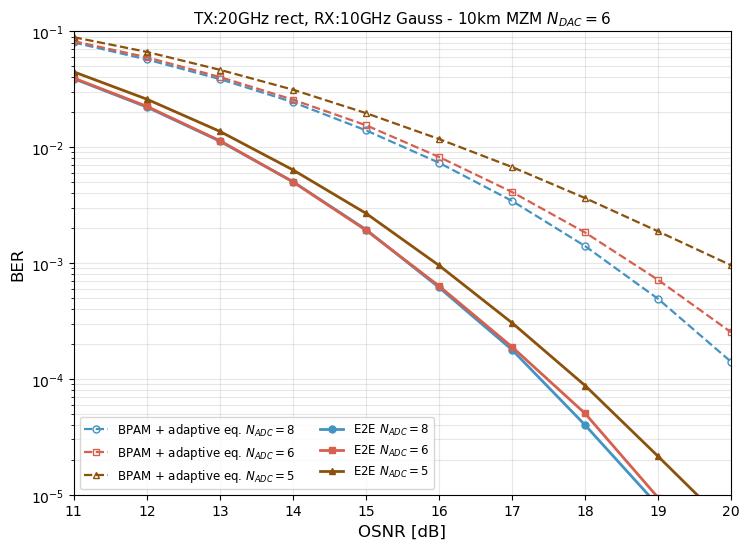

In [14]:
import shutil

STYLE = {8: ("o", "#4393c3"), 6: ("s", "#d6604d"), 5: ("^", "#8c510a")}
V3FIGS = r"C:\Users\celli\Documents\MATLAB\JLT_invited_OFC v3\figs"

def figure(axis, grid, xlabel, bkey, fname):
    fig, ax = plt.subplots(figsize=(7.6, 5.6))
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        pts = [(x, y) for x, y in zip(baseline[nb][bkey], baseline[nb]["ber"]) if y > 0]
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], "--" + mk, color=c, lw=1.6,
                    ms=5, mfc="none", label=f"BPAM + adaptive eq. $N_{{ADC}}={nb}$")
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        ax.semilogy(grid, np.maximum(results[axis][nb], 1e-7), "-" + mk, color=c, lw=2,
                    ms=5, label=f"E2E $N_{{ADC}}={nb}$")
    ax.set_xlim(min(grid), max(grid)); ax.set_ylim(1e-5, 1e-1); ax.set_xticks(grid)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("BER", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8.5, loc="lower left", ncol=2)
    ax.set_title("TX:20GHz rect, RX:10GHz Gauss - 10km MZM $N_{DAC}=6$", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, fname + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(OUT, fname + ".png"), bbox_inches="tight", dpi=150)
    try:
        shutil.copy(os.path.join(OUT, fname + ".pdf"), os.path.join(V3FIGS, fname + ".pdf"))
    except (PermissionError, FileNotFoundError) as e:
        print("v3 figs copy skipped:", e)
    plt.show()

figure("osnr", OSNR_GRID, "OSNR [dB]", "osnr", "complex_osnr_dario")

## 6b. Eye diagram at the matched-filter output

As in `pam4_analysis`: noiseless waveform of each trained transmitter, matched-filter output,
sampled at the phase that best separates the levels. With the discovered signaling the eye can
look closed — the decision lives in the RX context window, the eye documents the waveform.

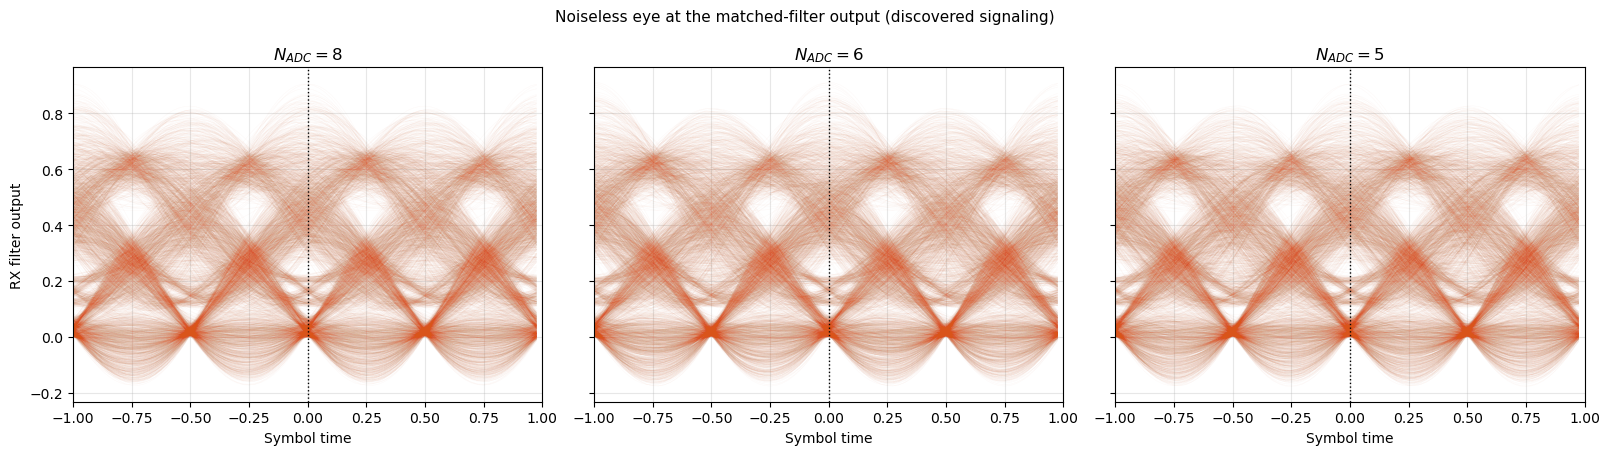

In [15]:
import torch.nn.functional as F
from scipy.signal import resample_poly
from train import random_bits
from transmitter import bits_to_symbols
from utils import decision_phase_by_separation

def draw_eye(ax, signal, samples_per_symbol, phase, title, fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(signal[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_title(title)

fig, axes = plt.subplots(1, len(nets), figsize=(5.4 * len(nets), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, (adc, (tx, ch, rx, cfg)) in zip(axes, nets.items()):
    sps = cfg.samples_per_symbol_sim
    mf_pad = rx.matched.shape[-1] // 2
    torch.manual_seed(7)
    with torch.no_grad():
        bits = random_bits(cfg.bits_per_symbol, 6000, device)
        symbols = bits_to_symbols(bits, cfg.bits_per_symbol).cpu().numpy()
        fr, fi = ch.complex_envelope(tx(bits), None)          # noiseless optical field
        mr = F.conv1d(fr.view(1, 1, -1), rx.matched, padding=mf_pad).squeeze()
        mi = F.conv1d(fi.view(1, 1, -1), rx.matched, padding=mf_pad).squeeze()
        matched = (mr ** 2 + mi ** 2).cpu().numpy()
    phase, _ = decision_phase_by_separation(matched, sps, symbols, skip=100)
    title = "ideal ADC" if adc is None else f"$N_{{ADC}}={adc}$"
    draw_eye(ax, matched, sps, phase, title)
axes[0].set_ylabel("RX filter output")
fig.suptitle("Noiseless eye at the matched-filter output (discovered signaling)", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "complex_eyes.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Horizontal gain vs the reference, at equal ADC resolution

In [16]:
def crossing(x, y, target):
    x = np.asarray(x, float)
    ly = np.log10(np.maximum(np.asarray(y, float), 1e-12))
    lt = np.log10(target)
    for i in range(len(x) - 1):
        if (ly[i] - lt) * (ly[i + 1] - lt) <= 0:
            return x[i] + (x[i + 1] - x[i]) * (lt - ly[i]) / (ly[i + 1] - ly[i])
    return np.nan

for target in (1e-2, 1e-3):
    print(f"\nBER = {target:.0e}   (Eb/N0 axis)")
    for nb in ADC_BITS:
        bx = [x for x, y in zip(baseline[nb]["ebn0"], baseline[nb]["ber"]) if y > 0]
        by = [y for y in baseline[nb]["ber"] if y > 0]
        gb = crossing(bx, by, target)
        ge = crossing(EBN0_GRID, results["ebn0"][nb], target)
        print(f"  N_ADC={nb}:  baseline @ {gb:5.2f} dB   E2E @ {ge:5.2f} dB"
              f"   ->  gain {gb - ge:+.2f} dB")


BER = 1e-02   (Eb/N0 axis)
  N_ADC=8:  baseline @ 13.47 dB   E2E @ 11.10 dB   ->  gain +2.37 dB
  N_ADC=6:  baseline @ 13.64 dB   E2E @ 11.12 dB   ->  gain +2.52 dB
  N_ADC=5:  baseline @ 14.24 dB   E2E @ 11.34 dB   ->  gain +2.90 dB

BER = 1e-03   (Eb/N0 axis)
  N_ADC=8:  baseline @ 16.27 dB   E2E @ 13.53 dB   ->  gain +2.74 dB
  N_ADC=6:  baseline @ 16.59 dB   E2E @ 13.56 dB   ->  gain +3.03 dB
  N_ADC=5:  baseline @ 17.88 dB   E2E @ 13.97 dB   ->  gain +3.91 dB
